# AdvViT — single-image attack test

Runs the hard-label black-box AdvViT attack (patch-wise DCT + Sign-OPT) against one image, then reports and visualizes the result.

Run this from inside `/home/siddharthsajjive/AdvViT` (Jupyter kernel using the `tea` conda env) so the relative imports (`simp`, `models.DeiT`, `models.resnet`) resolve correctly.

In [30]:
import os
import torch
from PIL import Image
import torchvision.transforms as T
import numpy as np
import matplotlib.pyplot as plt

from simp import SimP
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

device = torch.device('cuda', 0)
print('CUDA available:', torch.cuda.is_available())
print('Device:', device)

CUDA available: True
Device: cuda:0


## 1. Choose and load a model

DeiT (ViT-style, `forward()` returns `(logits, attention_list)`) is the default below.

To use ResNet50 instead (CNN-style, `forward()` returns plain logits), comment out the DeiT block and uncomment the ResNet block.

In [31]:

# ---- uncomment ONE of these ----
# MODEL_CHOICE = 'DeiT_T'
# MODEL_CHOICE = 'DeiT_S'
# MODEL_CHOICE = 'DeiT_B'
# MODEL_CHOICE = 'ResNet18'
MODEL_CHOICE = 'ResNet50'
# MODEL_CHOICE = 'ResNet101'
# MODEL_CHOICE = 'ResNet152'
# MODEL_CHOICE = 'VGG16'
# MODEL_CHOICE = 'Swin_T'
# MODEL_CHOICE = 'Swin_S'
# MODEL_CHOICE = 'Swin_B'
# MODEL_CHOICE = 'ViT_B'   # patch_size=32, not 16 -- see earlier note

if MODEL_CHOICE == 'DeiT_T':
    from models.DeiT import deit_tiny_patch16_224
    model = deit_tiny_patch16_224(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'DeiT_S':
    from models.DeiT import deit_small_patch16_224
    model = deit_small_patch16_224(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'DeiT_B':
    from models.DeiT import deit_base_patch16_224
    model = deit_base_patch16_224(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'ResNet18':
    import torchvision
    model = torchvision.models.resnet18(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'ResNet50':
    from models.resnet import ResNet50
    model = ResNet50(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'ResNet101':
    from models.resnet import ResNet101
    model = ResNet101(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'ResNet152':
    from models.resnet import ResNet152
    model = ResNet152(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'VGG16':
    import torchvision
    model = torchvision.models.vgg16(pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'Swin_T':
    import timm
    model = timm.models.create_model('swin_tiny_patch4_window7_224', pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'Swin_S':
    import timm
    model = timm.models.create_model('swin_small_patch4_window7_224', pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'Swin_B':
    import timm
    model = timm.models.create_model('swin_base_patch4_window7_224', pretrained=True).to(device).eval()
elif MODEL_CHOICE == 'ViT_B':
    import timm
    model = timm.create_model('vit_base_patch32_224.augreg_in1k', pretrained=True).to(device).eval()
else:
    raise ValueError(f'Unknown MODEL_CHOICE: {MODEL_CHOICE}')

print(f'Loaded {MODEL_CHOICE}')

Loading......
Loaded ResNet50


## 2. Load and preview the input image

`IMAGE_PATH` must be a Linux-style path (forward slashes), not a Windows one.

The image is resized to 224x224 and kept in raw `[0,1]` range — `SimP.normalize()` applies ImageNet mean/std internally, so don't normalize it yourself here.

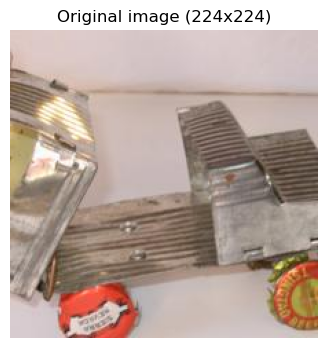

In [32]:
IMAGE_PATH = '/home/siddharthsajjive/TEA/ATTACK/ILSVRC2012_val_pairs/4a.JPEG' 
#IMAGE_PATH = '/home/siddharthsajjive/AdvViT/save/ori/ori0.jpg'  # <-- change this

img = Image.open(IMAGE_PATH).convert('RGB').resize((224, 224))
x0 = T.ToTensor()(img).to(device)  # [3,224,224], range [0,1]

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.title('Original image (224x224)')
plt.axis('off')
plt.show()

## 3. Get the clean prediction

This is `y0` — the label the untargeted attack will try to push the model *away* from.

In [33]:
attacker = SimP(model, 'imagenet', image_size=224)

with torch.no_grad():
    y0 = attacker.get_label(x0.unsqueeze(0))

print(f'Clean prediction (class index): {y0.item()}')

Clean prediction (class index): 491


## 4. Run the attack

This is the slow part — expect several minutes depending on `query_limit` and GPU. Progress prints every 10 iterations (from inside `attack_untargeted`), same as the script version.

In [34]:
import time

print(MODEL_CHOICE)
patch_size = 16
patch_num = 224 // patch_size
QUERY_LIMIT = 4000

t0 = time.time()
adv, distortion, is_success, nqueries, prub = attacker.attack_untargeted(
    x0, y0, ori_probal=None, patch_num=patch_num, query_limit=QUERY_LIMIT,
    use_sign_opt_plus=True
)
elapsed = time.time() - t0

print(f'Attack finished in {elapsed:.1f}s ({elapsed/60:.2f} min).')

ResNet50
Searching for the initial direction on 100 random directions: 
Dct mask:(1, 3, 224, 224)
--------> Found l2distortion 6.9390,dctdistortion6.9966
--------> Found l2distortion 5.1374,dctdistortion5.1646
--------> Found l2distortion 3.6761,dctdistortion3.6957
--------> Found l2distortion 3.2388,dctdistortion3.2689
--------> Found l2distortion 3.0409,dctdistortion3.0518
==========> Found best distortion 3.0409using 1311 queries
Iteration  10 distortion 1.3048 num_queries 3716
--------> sign opt attack  1.3005
Attack finished in 226.1s (3.77 min).


## 5. Results — attack outcome, L2 distortion, SSIM, PSNR

In [35]:
adv_np = adv.squeeze(0).detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy()
ori_np = x0.detach().cpu().permute(1, 2, 0).numpy()

ssim_val = ssim_fn(ori_np, adv_np, channel_axis=2, data_range=1.0)
psnr_val = psnr_fn(ori_np, adv_np, data_range=1.0)

with torch.no_grad():
    adv_pred = attacker.get_label(adv.to(device) if adv.dim() == 4 else adv.unsqueeze(0).to(device))

print('=' * 50)
print(f'{"Success:":<20}{bool(is_success)}')
print(f'{"Queries used:":<20}{nqueries} / {QUERY_LIMIT}')
print(f'{"L2 distortion:":<20}{distortion:.4f}')
print(f'{"SSIM:":<20}{ssim_val:.4f}   (1.0 = identical, closer to 1 = more visually similar)')
print(f'{"PSNR:":<20}{psnr_val:.2f} dB   (higher = more visually similar)')
print(f'{"Original class:":<20}{y0.item()}')
print(f'{"Adversarial class:":<20}{adv_pred.item()}')
print('=' * 50)

Success:            True
Queries used:       4150 / 4000
L2 distortion:      1.3005
SSIM:               0.9987   (1.0 = identical, closer to 1 = more visually similar)
PSNR:               49.49 dB   (higher = more visually similar)
Original class:     491
Adversarial class:  588


## 6. Visualize: original vs adversarial vs perturbation

Image saved to AdvViT/save
Image saved to AdvViT/save


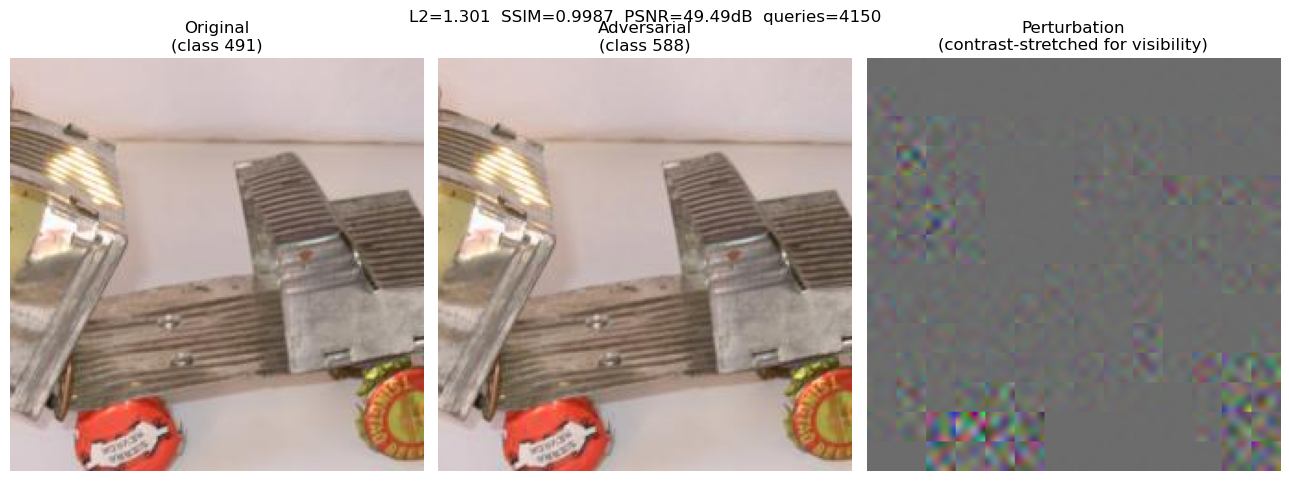

In [36]:
SAVE_NAME = f'insect_{MODEL_CHOICE}'
print("Image saved to AdvViT/save")  # <-- change this per run, e.g. 'dog_photo', 'run2', etc.

# amplify the perturbation for visibility -- raw diff is usually near-invisible
diff = adv_np - ori_np
diff_vis = (diff - diff.min()) / (diff.max() - diff.min() + 1e-8)

fig, axes = plt.subplots(1, 3, figsize=(13, 5))

axes[0].imshow(ori_np)
axes[0].set_title(f'Original\n(class {y0.item()})')
axes[0].axis('off')

axes[1].imshow(adv_np)
axes[1].set_title(f'Adversarial\n(class {adv_pred.item()})')
axes[1].axis('off')

axes[2].imshow(diff_vis)
axes[2].set_title('Perturbation\n(contrast-stretched for visibility)')
axes[2].axis('off')

fig.suptitle(f'L2={distortion:.3f}  SSIM={ssim_val:.4f}  PSNR={psnr_val:.2f}dB  queries={nqueries}', fontsize=12)
plt.tight_layout()

# Save the full 3-panel figure -- Linux-side path, matches what
# \\wsl.localhost\Ubuntu\home\siddharthsajjive\AdvViT\save maps to
SAVE_NAME = f'tortoise_{MODEL_CHOICE}'
print("Image saved to AdvViT/save") 
save_dir = '/home/siddharthsajjive/AdvViT/save'
os.makedirs(save_dir, exist_ok=True)
fig.savefig(os.path.join(save_dir, f'output_ad+_{SAVE_NAME}.png'), dpi=150, bbox_inches='tight')
plt.show()

## 7. Save outputs to disk

In [37]:
# out_dir = '/home/siddharthsajjive/AdvViT/save/single_test'
# os.makedirs(out_dir, exist_ok=True)

# T.ToPILImage()(x0.cpu()).save(os.path.join(out_dir, 'original.jpg'))
# T.ToPILImage()(adv.squeeze(0).cpu().clamp(0, 1)).save(os.path.join(out_dir, 'adversarial.jpg'))
# print(f'Saved original.jpg and adversarial.jpg to {out_dir}')


